In [1]:
import pandas as pd, numpy as np
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from sklearn.decomposition import PCA
import dcor
import itertools
import joblib
import plot_style as ps

In [2]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q, "w":w, "eps": eps, "alpha": alpha}

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query /= scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query


In [99]:
np.random.seed(0)

def swiss_roll(n: int = 2000):
    theta = np.random.uniform(low=3*np.pi/2, high=9*np.pi/2, size=n)
    z = np.random.uniform(low=0, high=20, size=n)
    x, y = theta*np.cos(theta), theta*np.sin(theta)
    X = np.stack((x,y,z), axis=1)
    S = 1/2 * (theta * np.sqrt(1 + theta**2) + np.arcsinh(theta))
    I = np.stack((S, z), axis=1)
    return X, I

X, I = swiss_roll(5000)

np.random.seed(0)

def two_sphere(n: int = 2000):
    u, v = np.random.uniform(low=0, high=1, size=n), np.random.uniform(low=0, high=1, size=n)
    theta = np.arccos(1 - 2*u)
    phi = 2 * np.pi * v
    X = np.stack((np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)), axis=1)

    intrinsic = np.stack((theta, phi), axis=1)
    return X, intrinsic

X_sphere, I_sphere = two_sphere(5000)

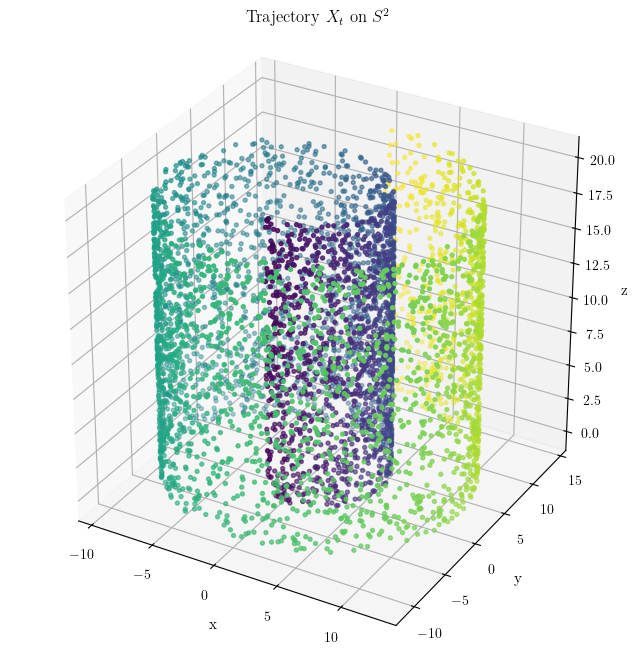

In [70]:
r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
fig = plt.figure(figsize=(8, 8)); ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=8, c=r)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(r'Trajectory $X_t$ on $S^2$'); plt.show()

In [90]:
EPS = 4.47      # [C2] chosen value
R = 2           # [C3] meaningful embedding dimension (largest gap at 2->3)
diff = diffusion_map(X, eps=EPS, k=R)
Psi = diff["Psi"][:, :R]              # [C3] restrict to meaningful coords
print(f"\nUsing eps={EPS}, r={R}. Psi shape = {Psi.shape}")


Using eps=4.47, r=2. Psi shape = (5000, 2)


In [92]:
def knn_graph_checks(Psi, k, sample_skip=50, jump_thresh=8.0):
    N = Psi.shape[0]
    A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
    A_bin  = kneighbors_graph(Psi, n_neighbors=k, mode="connectivity", include_self=False)
    A_dist_sym = A_dist.maximum(A_dist.T); A_bin_sym = A_bin.maximum(A_bin.T)
    n_comp, _ = connected_components(A_bin_sym, directed=False)
    degree = np.asarray(A_bin_sym.sum(1)).ravel()
    edges = A_bin_sym.nnz/2; density = edges/(N*(N-1)/2)
    _, pred = shortest_path(A_dist_sym, directed=False, return_predecessors=True)
    jr = []
    for a in range(1, N, sample_skip):
        for b in range(a+1, N, sample_skip):
            path = reconstruct_path(pred, a, b)
            if path is None or len(path) < 2: continue
            el = np.array([A_dist_sym[path[t], path[t+1]] for t in range(len(path)-1)])  # [C7] renamed t
            med = np.median(el)
            if med > 1e-12: jr.append(el.max()/med)
    jr = np.array(jr); jr95 = np.quantile(jr, 0.95)
    accept = (n_comp == 1) and (density < 0.5) and (jr95 < jump_thresh)   # [C5] real criterion
    return dict(k=k, components=n_comp, mean_degree=degree.mean(), density=density,
                max_edge=A_dist_sym.data.max(), median_edge=np.median(A_dist_sym.data),
                jump95=jr95, status="Accepted" if accept else "Rejected")

rows = [knn_graph_checks(Psi, k) for k in [50, 90]]
graph_df = pd.DataFrame(rows).set_index("k")
print(graph_df.round(4).to_string())

    components  mean_degree  density  max_edge  median_edge  jump95    status
k                                                                            
50           1      53.5928   0.0107    0.0075       0.0012  2.8887  Accepted
90           1      96.3200   0.0193    0.0122       0.0021  2.6764  Accepted


In [93]:
h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

A_dist = kneighbors_graph(Psi, n_neighbors=30, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

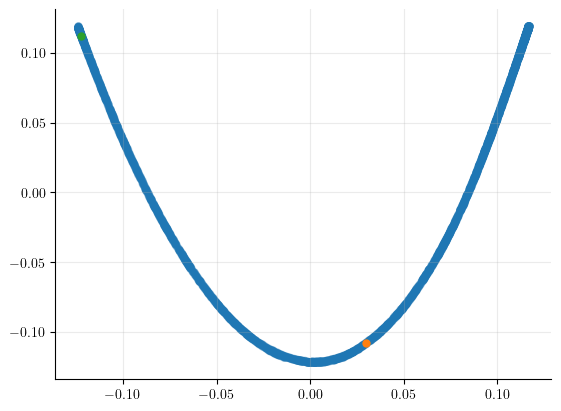

In [95]:

idx_start = 0
idx_end = 8
idx_graph = graph_path(A_dist_sym, beta=0, V=V, start=idx_start, end=idx_end)

plt.scatter(Psi[:, 0], Psi[:, 1], alpha=0.2)
plt.scatter(Psi[idx_start, 0], Psi[idx_start, 1])
plt.scatter(Psi[idx_end, 0], Psi[idx_end, 1])
# plt.plot(Psi[idx_graph, 0], Psi[idx_graph, 1], color="r")


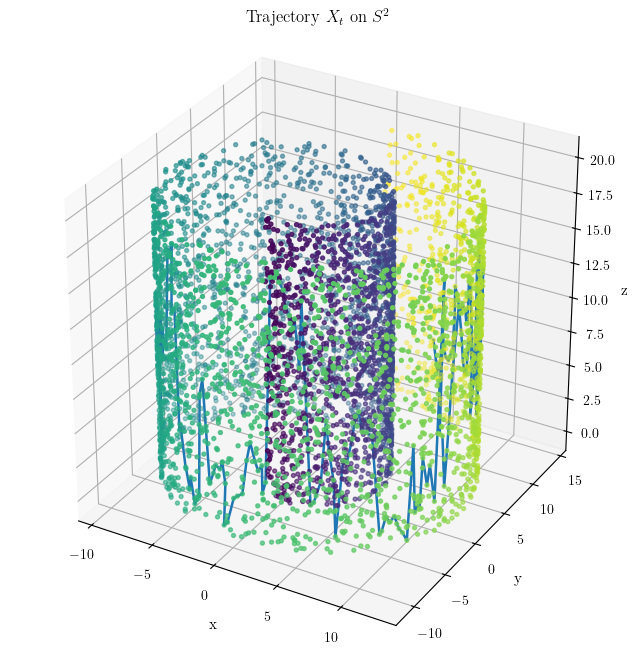

In [98]:
r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
fig = plt.figure(figsize=(8, 8)); ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=8, c=r)
ax.plot(X[idx_graph, 0], X[idx_graph, 1], X[idx_graph, 2])
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(r'Trajectory $X_t$ on $S^2$'); plt.show()